In [1]:
import pandas as pd
import requests
import json
import matplotlib.pyplot as plt

In [4]:
url = "https://github.com/alura-cursos/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


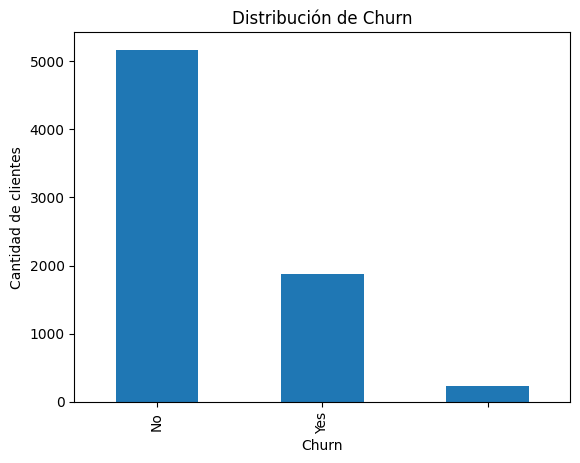

In [12]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

In [16]:
pd.crosstab(df["account.Contract"], df["Churn"])

Churn,,No,Yes
account.Contract,,,
Month-to-month,130,2220,1655
One year,46,1307,166
Two year,48,1647,48


In [17]:
pd.crosstab(df["account.PaymentMethod"], df["Churn"])

Churn,,No,Yes
account.PaymentMethod,,,
Bank transfer (automatic),45,1286,258
Credit card (automatic),46,1290,232
Electronic check,80,1294,1071
Mailed check,53,1304,308


In [18]:
df.groupby("Churn")["account.Charges.Monthly"].mean()

,account.Charges.Monthly
Churn,
,63.412277
No,61.265124
Yes,74.441332


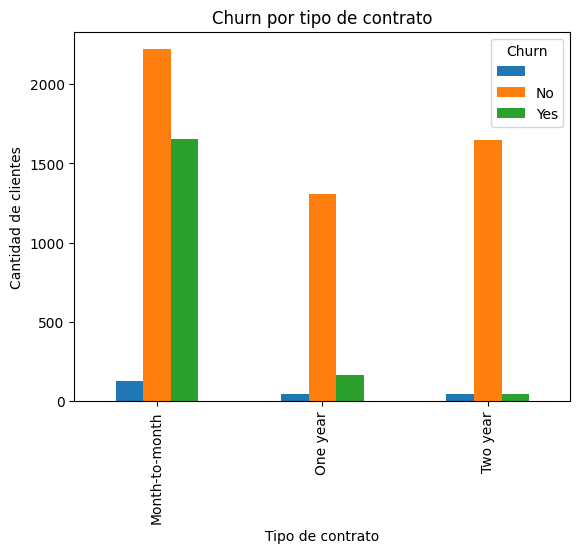

In [19]:
df.groupby("account.Contract")["Churn"].value_counts().unstack().plot(kind="bar")

plt.title("Churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")

plt.show()

In [21]:
pd.crosstab(df["account_Contract"], df["Churn"])

Churn,,No,Yes
account_Contract,,,
Month-to-month,130,2220,1655
One year,46,1307,166
Two year,48,1647,48


In [26]:
pd.crosstab(df["account_PaymentMethod"], df["Churn"])

Churn,,No,Yes
account_PaymentMethod,,,
Bank transfer (automatic),45,1286,258
Credit card (automatic),46,1290,232
Electronic check,80,1294,1071
Mailed check,53,1304,308


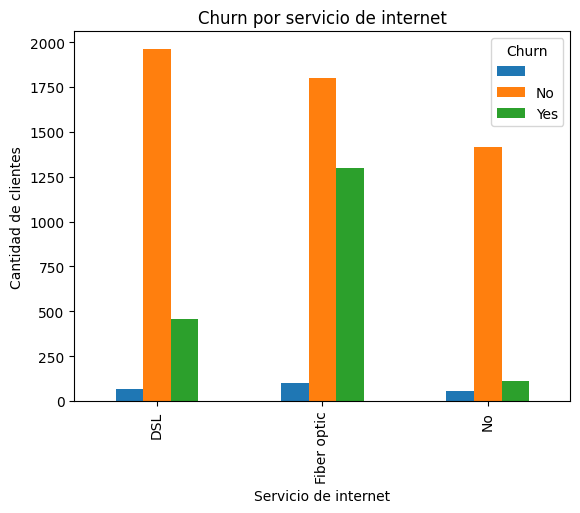

In [33]:
pd.crosstab(df["internet_InternetService"], df["Churn"]).plot(kind="bar")

plt.title("Churn por servicio de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Cantidad de clientes")

plt.show()

In [35]:
df.groupby("Churn")["account_Charges_Monthly"].mean()

,account_Charges_Monthly
Churn,
,63.412277
No,61.265124
Yes,74.441332


<Axes: title={'center': 'account_Charges_Monthly'}, xlabel='Churn'>

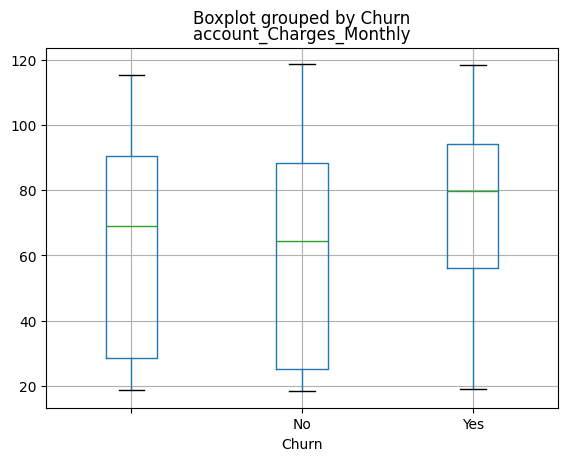

In [36]:
df.boxplot(column="account_Charges_Monthly", by="Churn")

El análisis exploratorio de los datos de Telecom X permitió identificar algunos factores asociados a la evasión de clientes.

Los clientes con contratos mensuales presentan una mayor tasa de cancelación, lo que indica menor fidelización. También se observa que los cargos mensuales más altos pueden influir en la decisión de cancelar el servicio.

Estos resultados pueden ayudar a la empresa a desarrollar estrategias para mejorar la retención de clientes y reducir el churn.